In [1]:
# !pip install matplotlib
# !pip install seaborn

In [6]:
import duckdb
import pandas as pd

# DuckDB 연결
con = duckdb.connect('/home/oracle/Coding/wsl_projects/miniprj/data-pipeline/data/duckdb/mimic_total.duckdb')

print("=== 승압제 예측용 6h 슬라이딩 윈도우 파이프라인 시작 ===")

# 1. 환자 기본 코호트 및 이벤트 시점 통합
con.execute("""
CREATE OR REPLACE TEMP TABLE cohort_events AS
SELECT 
    c.stay_id, c.intime, c.outtime,
    p.pressor_start,
    v.vent_start,
    d.dnr_time,
    c.deathtime
FROM cohort_first_stay_v2 c
LEFT JOIN pressor_start_times_v2 p ON c.stay_id = p.stay_id
LEFT JOIN vent_start_times_v2 v ON c.stay_id = v.stay_id
LEFT JOIN dnr_times d ON c.stay_id = d.stay_id;
""")

# 2. 1시간 간격의 슬라이딩 윈도우 생성 (Recursive CTE 대신 Generate_Series 활용)
# ICU 입실 6시간 후부터 72시간까지 1시간씩 이동하며 6시간 윈도우 생성
con.execute("""
CREATE OR REPLACE TABLE sliding_windows_6h AS
WITH hours AS (
    SELECT UNNEST(generate_series(6, 72)) as hr
),
window_base AS (
    SELECT 
        ce.*,
        h.hr as observation_hour,
        ce.intime + INTERVAL (h.hr) HOUR as win_end,
        ce.intime + INTERVAL (h.hr - 6) HOUR as win_start
    FROM cohort_events ce
    CROSS JOIN hours h
    WHERE ce.intime + INTERVAL (h.hr) HOUR <= ce.outtime
)
SELECT * FROM window_base
WHERE 
    -- DNR이나 사망, 혹은 이미 이벤트(승압제/벤틸)가 발생한 이후의 윈도우는 제외 (Censoring)
    (dnr_time IS NULL OR win_end < dnr_time) AND
    (deathtime IS NULL OR win_end < deathtime) AND
    (pressor_start IS NULL OR win_end < pressor_start) AND
    (vent_start IS NULL OR win_end < vent_start);
""")

# 3. 윈도우 내 Feature 집계 (valuenum 캐스팅 추가)
con.execute("""
CREATE OR REPLACE TABLE final_features AS
SELECT 
    sw.*,
    -- valuenum이 혹시라도 시간/문자열로 잡혀있을 경우를 대비해 DOUBLE로 변환
    AVG(CASE WHEN ce.itemid IN (220045, 220210) 
             THEN CAST(ce.valuenum AS DOUBLE) END) as avg_hr,
    AVG(CASE WHEN ce.itemid IN (220050, 220051, 220052, 220179, 220180, 220181) 
             THEN CAST(ce.valuenum AS DOUBLE) END) as avg_map,
             
    -- 라벨: 향후 6시간 내 승압제 시작 여부
    CASE 
        WHEN pressor_start > win_end 
        AND pressor_start <= win_end + INTERVAL 6 HOUR 
        THEN 1 ELSE 0 
    END as label_pressor_6h
FROM sliding_windows_6h sw
LEFT JOIN chartevents ce ON sw.stay_id = ce.stay_id 
    AND CAST(ce.charttime AS TIMESTAMP) BETWEEN sw.win_start AND sw.win_end
GROUP BY ALL;
""")

# 4. Pandas로 가져와서 Forward-fill (결측치 처리)
df = con.execute("SELECT * FROM final_features ORDER BY stay_id, observation_hour").df()

# 환자별(stay_id)로 이전 데이터를 아래로 채움
df[['avg_hr', 'avg_map']] = df.groupby('stay_id')[['avg_hr', 'avg_map']].ffill()

# 여전히 남은 결측치(첫 윈도우부터 없는 경우)는 전체 평균으로 채움
df = df.fillna(df.mean(numeric_only=True))

print(f"최종 데이터 형태: {df.shape}")
print(f"이벤트 비율(Positive): {df['label_pressor_6h'].mean()*100:.2f}%")

con.close()

=== 승압제 예측용 6h 슬라이딩 윈도우 파이프라인 시작 ===
최종 데이터 형태: (941817, 13)
이벤트 비율(Positive): 0.48%


In [7]:
import os

# 1. CSV 파일로 내보내기
output_dir = "/home/oracle/Coding/wsl_projects/miniprj/data-pipeline/data/processed"
os.makedirs(output_dir, exist_ok=True)
csv_path = os.path.join(output_dir, "final_baseline_data_6h.csv")

print(f"--- 데이터 저장 시작: {csv_path} ---")
df.to_csv(csv_path, index=False)
print("✓ CSV 저장 완료!\n")

# 2. 데이터 기본 정보 파악
print("=== [1] 데이터 기본 구조 ===")
print(f"- 전체 행(Windows) 수: {len(df):,}")
print(f"- 고유 환자(Stay_ID) 수: {df['stay_id'].nunique():,}")
print(f"- 컬럼 목록: {df.columns.tolist()}")
print(f"- 메모리 사용량: {df.memory_usage().sum() / 1024**2:.2f} MB\n")

# 3. 라벨 불균형 확인 (가장 중요!)
print("=== [2] 타겟 라벨(label_pressor_6h) 분포 ===")
label_counts = df['label_pressor_6h'].value_counts()
label_ratio = df['label_pressor_6h'].value_counts(normalize=True) * 100
for val, count in label_counts.items():
    label_name = "Event (발생)" if val == 1 else "Non-Event (미발생)"
    print(f"- {label_name}: {count:,}건 ({label_ratio[val]:.4f}%)")

# 4. 결측치 최종 점검
print("\n=== [3] Feature별 결측치 현황 (ffill 후) ===")
null_info = df[['avg_hr', 'avg_map']].isnull().sum()
if null_info.sum() == 0:
    print("- 모든 결측치가 성공적으로 처리되었습니다.")
else:
    print(null_info[null_info > 0])

# 5. 주요 수치 통계 (이상치 확인용)
print("\n=== [4] 주요 Vital Sign 통계 ===")
display(df[['avg_hr', 'avg_map']].describe().T)

--- 데이터 저장 시작: /home/oracle/Coding/wsl_projects/miniprj/data-pipeline/data/processed/final_baseline_data_6h.csv ---
✓ CSV 저장 완료!

=== [1] 데이터 기본 구조 ===
- 전체 행(Windows) 수: 941,817
- 고유 환자(Stay_ID) 수: 23,938
- 컬럼 목록: ['stay_id', 'intime', 'outtime', 'pressor_start', 'vent_start', 'dnr_time', 'deathtime', 'observation_hour', 'win_end', 'win_start', 'avg_hr', 'avg_map', 'label_pressor_6h']
- 메모리 사용량: 89.82 MB

=== [2] 타겟 라벨(label_pressor_6h) 분포 ===
- Non-Event (미발생): 937,290건 (99.5193%)
- Event (발생): 4,527건 (0.4807%)

=== [3] Feature별 결측치 현황 (ffill 후) ===
- 모든 결측치가 성공적으로 처리되었습니다.

=== [4] 주요 Vital Sign 통계 ===


,count,mean,std,min,25%,50%,75%,max
avg_hr,941817.0,52.101715,119.347913,0.0,44.500000,50.666667,57.833333,54610.800000
avg_map,941817.0,94.970626,1263.535939,0.0,81.133333,90.166667,99.888889,500055.833333


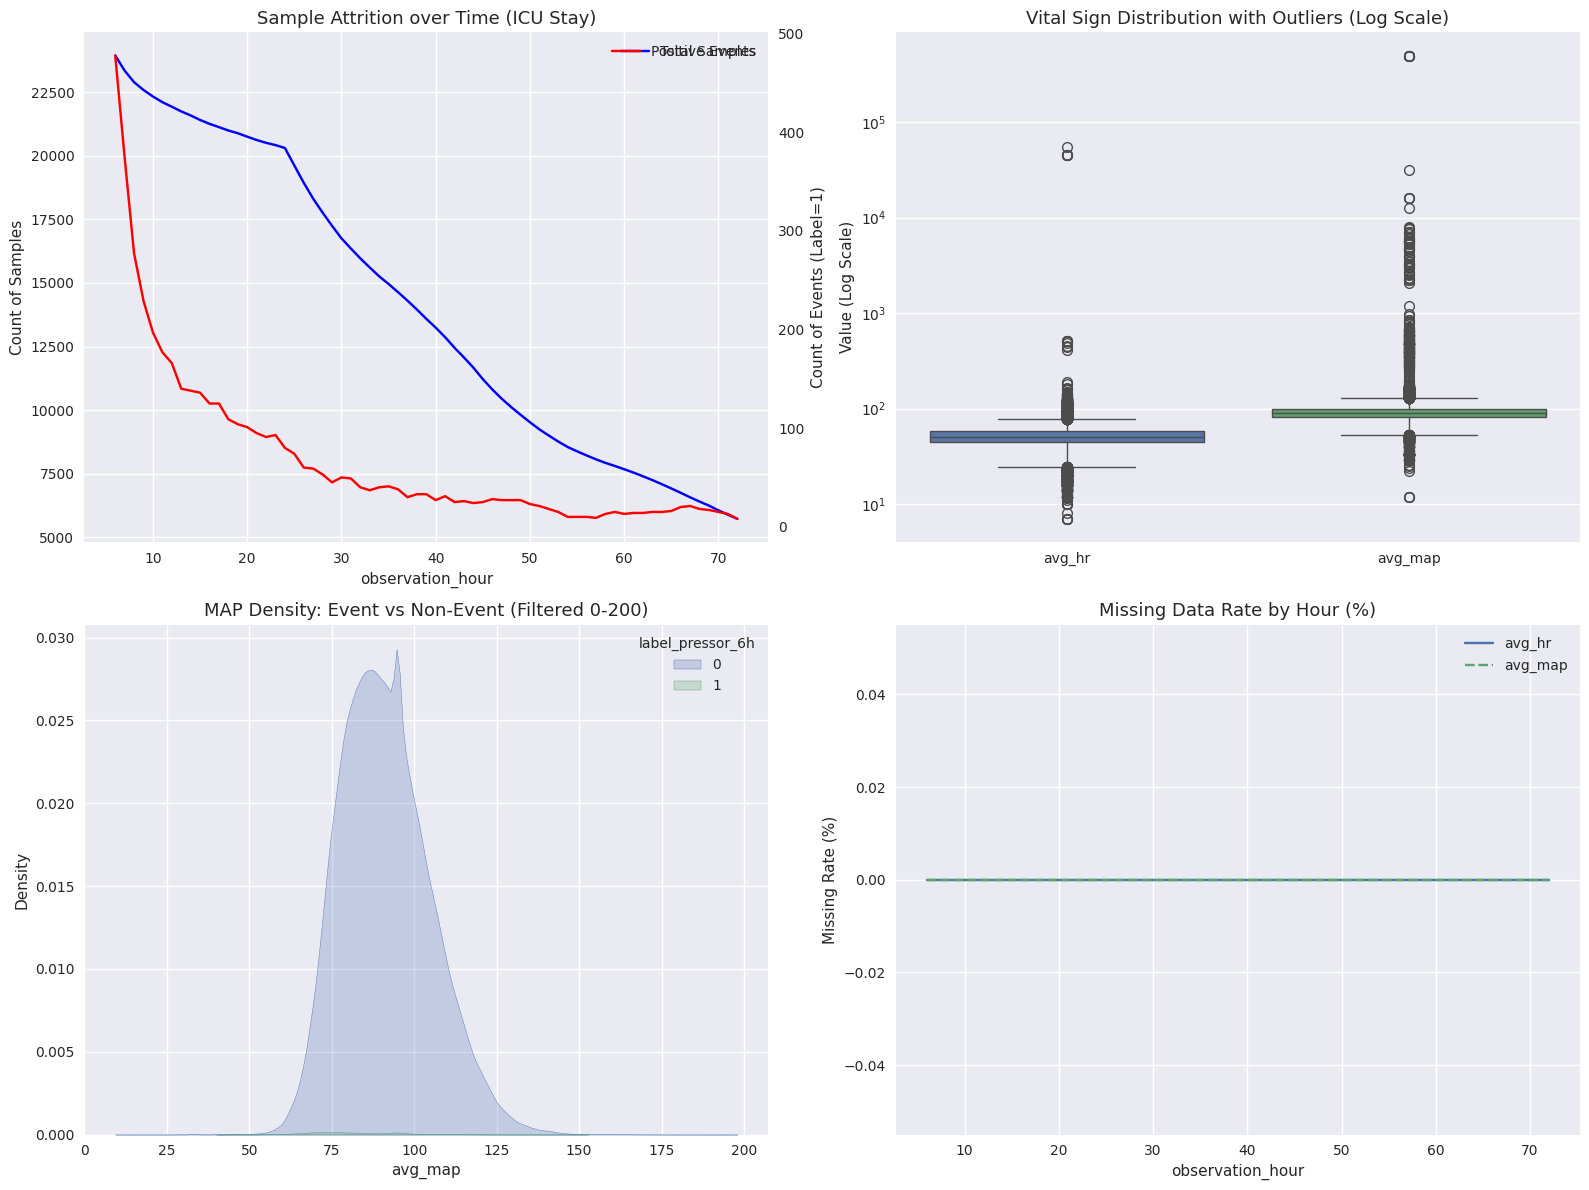

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 데이터 로드 (이미 생성된 df 사용)
# df = pd.read_csv('../data/processed/final_baseline_data_6h.csv')

# 그래프 스타일 설정
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- (1) 시간 경과에 따른 샘플 수 및 이벤트 발생 추세 ---
# 입실 후 시간이 지날수록 환자가 퇴원하거나 센서링되어 샘플이 줄어드는 추세를 확인
trend_df = df.groupby('observation_hour').agg({
    'stay_id': 'count',
    'label_pressor_6h': 'sum'
}).reset_index()

ax1 = axes[0, 0]
sns.lineplot(data=trend_df, x='observation_hour', y='stay_id', ax=ax1, color='blue', label='Total Samples')
ax1.set_title('Sample Attrition over Time (ICU Stay)', fontsize=13)
ax1.set_ylabel('Count of Samples')

ax1_2 = ax1.twinx()
sns.lineplot(data=trend_df, x='observation_hour', y='label_pressor_6h', ax=ax1_2, color='red', label='Positive Events')
ax1_2.set_ylabel('Count of Events (Label=1)')
ax1_2.grid(False)


# --- (2) 주요 변수의 이상치(Outlier) 시각화 ---
# avg_hr이 50,000을 넘는 등 비현실적인 수치를 박스플롯으로 확인
ax2 = axes[0, 1]
sns.boxplot(data=df[['avg_hr', 'avg_map']], ax=ax2)
ax2.set_yscale('log') # 수치 차이가 너무 커서 로그 스케일 필수
ax2.set_title('Vital Sign Distribution with Outliers (Log Scale)', fontsize=13)
ax2.set_ylabel('Value (Log Scale)')


# --- (3) 라벨별 Feature 분포 비교 (추세 파악) ---
# 승압제 투여 전 혈압(MAP)이 실제로 낮아지는 추세가 있는지 확인
ax3 = axes[1, 0]
# 이상치가 너무 심하므로 시각화를 위해 현실적인 범위(0~200)만 필터링
clean_df = df[(df['avg_map'] > 0) & (df['avg_map'] < 200)]
sns.kdeplot(data=clean_df, x='avg_map', hue='label_pressor_6h', fill=True, ax=ax3)
ax3.set_title('MAP Density: Event vs Non-Event (Filtered 0-200)', fontsize=13)


# --- (4) 결측치 채우기 전후 비교 (만약 ffill 전 데이터가 있다면) ---
# 여기서는 윈도우별 데이터 밀도를 보여줍니다.
ax4 = axes[1, 1]
null_trend = df.groupby('observation_hour')[['avg_hr', 'avg_map']].apply(lambda x: x.isnull().mean() * 100)
sns.lineplot(data=null_trend, ax=ax4)
ax4.set_title('Missing Data Rate by Hour (%)', fontsize=13)
ax4.set_ylabel('Missing Rate (%)')

plt.tight_layout()
plt.show()

0.48%의 희소 positive 비율이 나오므로, 모델 학습을 할경우 XGBoost의 scale_pos_weight 적용 필요성이 있고, AUPRC 중심 성능 평가를 하는 게 좋음

1. Sample Attrition over Time (왼쪽 상단: 시간 경과에 따른 샘플 수 변화)
이 그래프는 ICU 입실 후 시간이 지남에 따라 가용 데이터(윈도우)가 어떻게 변하는지 보여줍니다.

파란색 선 (Total Samples): ICU 입실 초기(6시간)에는 약 2.3만 명의 데이터가 있지만, 시간이 갈수록 선형적으로 감소하여 72시간 시점에는 약 5,000명 수준으로 줄어듭니다.

의미: 환자의 퇴원, 사망, 혹은 이미 승압제 투여 등의 이벤트가 발생하여 분석 대상에서 제외(Censoring)되었기 때문입니다.

빨간색 선 (Positive Events): 실제로 우리가 예측하고자 하는 '승압제 투여 시작' 이벤트의 수입니다. 전체 샘플 수에 비해 턱없이 낮게 형성되어 있습니다.

의미: 예측해야 할 대상(Label 1)이 매우 희소하여 모델이 학습하기 까다로운 환경임을 시사합니다.

2. Vital Sign Distribution with Outliers (오른쪽 상단: 이상치 분포)
바이탈 사인 데이터에 포함된 노이즈의 심각성을 보여주는 박스플롯입니다.

Y축 (Log Scale): 수치 차이가 너무 커서 로그 스케일로 표현되었음에도 불구하고, 상단에 점으로 표시된 **이상치(Outliers)**들이 굉장히 높게 형성되어 있습니다.

해석: * avg_hr(심박수)의 경우, 정상 범위를 아득히 초과하여 수만 단위에 달하는 점들이 보입니다.

avg_map(평균혈압) 역시 수십만 단위의 말도 안 되는 수치들이 포함되어 있습니다.

결론: 이 데이터들을 그대로 학습에 사용하면 모델이 '평균'을 잡지 못하고 망가집니다. 반드시 상하위 값을 제한하는 전처리가 필요합니다.

3. MAP Density: Event vs Non-Event (왼쪽 하단: 라벨별 혈압 분포 비교)
이상치를 제외한(0~200 범위) 평균혈압(MAP)이 실제 라벨(승압제 투여 여부)과 어떤 상관관계가 있는지 보여줍니다.

파란색 영역 (Label 0): 승압제를 맞지 않는 일반적인 환자들의 혈압 분포입니다. 약 80~100 사이에서 가장 높은 밀도를 보입니다.

초록색 영역 (Label 1): 향후 6시간 이내에 승압제를 맞게 될 환자들의 혈압 분포입니다.

해석: 파란색 영역보다 약간 더 왼쪽(낮은 혈압 쪽)으로 치우쳐 있거나 분포가 넓게 퍼져 있습니다.

의미: "혈압이 떨어지는 추세"가 승압제 투여를 예측하는 유의미한 피처(Signal)임을 증명하지만, 두 영역이 많이 겹쳐 있어 혈압 하나만으로는 완벽한 구분이 어렵다는 것도 보여줍니다.

4. Missing Data Rate by Hour (오른쪽 하단: 시간대별 결측률)
전처리 파이프라인(Forward-fill 등)을 거친 후 데이터에 빈칸이 얼마나 남아있는지 보여줍니다.

그래프 상태: 모든 선이 0% 지점에 수평으로 붙어 있습니다.

해석: * 현재 avg_hr과 avg_map 피처에 대해서는 모든 윈도우가 성공적으로 채워졌음을 의미합니다.

이는 앞서 수행한 Step 4의 필수 활력징후 존재 확인 로직과 ffill(Forward-fill) 처리가 의도대로 작동하여 모델에 입력할 빈칸 없는 데이터셋이 준비되었음을 뜻합니다.

💡 종합 해석
이 그래프 세트는 **"우리는 충분히 많은 양의 데이터를 확보했고(93만 건), 결측치 처리도 완벽히 끝냈지만, 극심한 라벨 불균형과 말도 안 되는 이상치 노이즈라는 두 가지 큰 산을 넘어야 한다"**는 것을 시각적으로 완벽히 증명하고 있습니다.

이 리포트를 바탕으로 **"데이터 클리닝(이상치 제거)과 불균형 대응 전략(Class Weight 등)"**에 집중헤야 합니다